# 08 — Evaluación Longitudinal Intrapersonal

**Objetivo:** Entrenar un modelo individual (kNN, SVM, ANN) por cada uno de los 19 usuarios
usando únicamente sus datos de **Mes0**, y evaluar ese modelo —sin reentrenar— contra los
meses siguientes de ese mismo usuario.

- **19 usuarios × 3 modelos = 57 modelos** entrenados.
- Hiperparámetros fijos (optimizados previamente en notebooks 04–06).
- Accuracy de Mes0 reportado mediante **validación cruzada estratificada** (5 folds).
- Resultados en formato largo para facilitar análisis estadístico futuro (Friedman/Wilcoxon).

## 0. Configuración del entorno

In [1]:
# ─── Montaje de Drive y configuración de rutas (Colab) ───
import os, sys

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    import glob, os
    paths = glob.glob('/content/drive/**/emg-classification-knn-svm-ann', recursive=True)
    pc = [p for p in paths if 'Othercomputers' in p or 'Ordenadores' in p]
    PROJECT_PATH = max(pc or paths, key=os.path.getmtime) if paths else '/content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann'
    os.chdir(PROJECT_PATH)
    sys.path.insert(0, PROJECT_PATH)
except:
    if 'notebooks' in os.getcwd(): os.chdir('..')
    sys.path.insert(0, os.getcwd())

print('CWD:', os.getcwd())

Mounted at /content/drive
CWD: /content/drive/Othercomputers/My PC (1)/emg-classification-knn-svm-ann


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from src.mat_loader import load_all_sessions
from src.intrapersonal import (
    build_features_by_user_month,
    train_user_models,
    evaluate_user_model,
    cross_validate_user_mes0,
    save_user_models,
    CLASS_NAMES,
    DEFAULT_ANN_PARAMS,
)
from src.visualization import get_user_color_map, plot_intrapersonal_accuracy

print('✅ Imports completados')

✅ Imports completados


## 2. Carga de datos longitudinales

In [3]:
BASE_DIR = Path('data/longitudinal/usuarios')

# Carga todas las sesiones (detecta Mes0..MesN dinámicamente)
sessions = load_all_sessions(BASE_DIR)

# Meses disponibles (ordenados)
MESES = sorted(sessions.keys(), key=lambda m: int(m.replace('Mes', '')))
print(f'\n📅 Meses detectados: {MESES}')
print(f'   Total de meses: {len(MESES)}')


📅 Cargando Mes0...
  Cargado user12: 300 repeticiones, 988 muestras × 8 canales
  Cargado user14: 300 repeticiones, 988 muestras × 8 canales
  Cargado user21: 300 repeticiones, 988 muestras × 8 canales
  Cargado user23: 300 repeticiones, 988 muestras × 8 canales
  Cargado user24: 300 repeticiones, 990 muestras × 8 canales
  Cargado user26: 300 repeticiones, 988 muestras × 8 canales
  Cargado user35: 300 repeticiones, 988 muestras × 8 canales
  Cargado user37: 300 repeticiones, 988 muestras × 8 canales
  Cargado user4: 300 repeticiones, 988 muestras × 8 canales
  Cargado user40: 300 repeticiones, 988 muestras × 8 canales
  Cargado user42: 300 repeticiones, 988 muestras × 8 canales
  Cargado user43: 300 repeticiones, 988 muestras × 8 canales
  Cargado user49: 300 repeticiones, 988 muestras × 8 canales
  Cargado user5: 300 repeticiones, 984 muestras × 8 canales
  Cargado user55: 300 repeticiones, 988 muestras × 8 canales
  Cargado user57: 300 repeticiones, 988 muestras × 8 canales
  Carg

## 3. Extracción de features por usuario y mes

Se extraen 72 features (9 métricas × 8 canales) por repetición, indexados por usuario y mes.

In [4]:
print('Extrayendo features por usuario y mes...')
features_by_user_month = build_features_by_user_month(sessions)

# Lista de usuarios (ordenados numéricamente)
USER_IDS = sorted(features_by_user_month.keys(),
                  key=lambda uid: int(uid.replace('user', '')))

print(f'\n✅ Features extraídas para {len(USER_IDS)} usuarios')
print(f'   Usuarios: {USER_IDS}')

# Verificación rápida: muestras por usuario en Mes0
print(f'\nMuestras en Mes0 por usuario:')
for uid in USER_IDS:
    X, y = features_by_user_month[uid]['Mes0']
    print(f'  {uid}: {X.shape[0]} repeticiones, {X.shape[1]} features')

Extrayendo features por usuario y mes...

✅ Features extraídas para 19 usuarios
   Usuarios: ['user4', 'user5', 'user6', 'user8', 'user9', 'user12', 'user14', 'user21', 'user23', 'user24', 'user26', 'user35', 'user37', 'user40', 'user42', 'user43', 'user49', 'user55', 'user57']

Muestras en Mes0 por usuario:
  user4: 300 repeticiones, 72 features
  user5: 300 repeticiones, 72 features
  user6: 300 repeticiones, 72 features
  user8: 300 repeticiones, 72 features
  user9: 300 repeticiones, 72 features
  user12: 300 repeticiones, 72 features
  user14: 300 repeticiones, 72 features
  user21: 300 repeticiones, 72 features
  user23: 300 repeticiones, 72 features
  user24: 300 repeticiones, 72 features
  user26: 300 repeticiones, 72 features
  user35: 300 repeticiones, 72 features
  user37: 300 repeticiones, 72 features
  user40: 300 repeticiones, 72 features
  user42: 300 repeticiones, 72 features
  user43: 300 repeticiones, 72 features
  user49: 300 repeticiones, 72 features
  user55: 300 r

## 4. Configuración de colores por usuario

In [5]:
# Colores consistentes para las 3 gráficas
user_colors = get_user_color_map(USER_IDS)
print(f'🎨 Mapa de colores generado para {len(user_colors)} usuarios')

🎨 Mapa de colores generado para 19 usuarios


## 5. Parámetros configurables de ANN

Estos parámetros se pueden ajustar si el entrenamiento de 19 ANNs es muy lento.

In [6]:
# Parámetros de ANN (ajustables)
ann_params = DEFAULT_ANN_PARAMS.copy()

# Descomentar para ajustar si es necesario:
# ann_params['epochs'] = 150
# ann_params['validation_split'] = 0.2
# ann_params['patience_es'] = 15
# ann_params['patience_lr'] = 5
# ann_params['batch_size'] = 16

print('Parámetros ANN:', ann_params)

Parámetros ANN: {'epochs': 200, 'batch_size': 32, 'validation_split': 0.15, 'patience_es': 20, 'patience_lr': 7, 'lr_factor': 0.5, 'verbose': 0}


## 6. Entrenamiento y evaluación intrapersonal

Para cada usuario:
1. Entrena 3 modelos (kNN, SVM, ANN) con su Mes0
2. Evalúa con **CV estratificada** en Mes0 (accuracy honesto)
3. Evalúa contra cada mes posterior sin reentrenar
4. Guarda los modelos en disco

In [7]:
# Directorios de salida
MODELS_DIR = Path('data/processed/models/intrapersonal')
RESULTS_DIR = Path('data/processed/results')
FIGURES_DIR = RESULTS_DIR / 'figures'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Acumulador de resultados
all_results = []
total_models_saved = 0

MODEL_NAMES = ['kNN', 'SVM', 'ANN']

for i_user, user_id in enumerate(USER_IDS):
    print(f'\n{"═" * 60}')
    print(f'👤 [{i_user+1}/{len(USER_IDS)}] Procesando {user_id}')
    print(f'{"═" * 60}')

    user_data = features_by_user_month[user_id]
    X_mes0, y_mes0 = user_data['Mes0']

    print(f'  Mes0: {X_mes0.shape[0]} muestras, {X_mes0.shape[1]} features')

    # ── 6.1 Entrenar los 3 modelos con Mes0 ──
    print(f'  Entrenando modelos...')
    models = train_user_models(X_mes0, y_mes0, CLASS_NAMES, ann_params=ann_params)

    # ── 6.2 Validación cruzada en Mes0 ──
    print(f'  Validación cruzada (Mes0)...')
    cv_results = cross_validate_user_mes0(
        X_mes0, y_mes0, CLASS_NAMES, n_splits=5, ann_params=ann_params
    )

    for model_name in MODEL_NAMES:
        cv_acc = cv_results[model_name]['accuracy'] * 100
        cv_std = cv_results[model_name]['std'] * 100
        n_splits = cv_results[model_name]['n_splits_used']
        print(f'    {model_name} CV ({n_splits}-fold): '
              f'{cv_acc:.2f}% (±{cv_std:.2f}%)')

        # Registrar resultado de Mes0 (con CV accuracy)
        all_results.append({
            'user_id': user_id,
            'model': model_name,
            'mes': 'Mes0',
            'mes_num': 0,
            'accuracy': cv_acc,
            'precision': np.nan,  # CV no reporta precision/recall individuales
            'recall': np.nan,
            'f1': np.nan,
            'n_samples': X_mes0.shape[0],
        })

    # ── 6.3 Evaluar contra meses posteriores ──
    for mes in MESES:
        if mes == 'Mes0':
            continue  # Ya registrado arriba con CV

        mes_num = int(mes.replace('Mes', ''))

        if mes not in user_data:
            print(f'  ⚠️  {mes}: no disponible para {user_id}')
            continue

        X_mes, y_mes = user_data[mes]

        for model_name in MODEL_NAMES:
            metrics = evaluate_user_model(
                models[model_name], X_mes, y_mes, model_name
            )
            all_results.append({
                'user_id': user_id,
                'model': model_name,
                'mes': mes,
                'mes_num': mes_num,
                'accuracy': metrics['accuracy'] * 100,
                'precision': metrics['precision'] * 100,
                'recall': metrics['recall'] * 100,
                'f1': metrics['f1'] * 100,
                'n_samples': X_mes.shape[0],
            })

        accs = {mn: evaluate_user_model(models[mn], X_mes, y_mes, mn)['accuracy']*100
                for mn in MODEL_NAMES}
        print(f'  {mes} ({X_mes.shape[0]} muestras): '
              + ' | '.join(f'{mn}: {accs[mn]:.1f}%' for mn in MODEL_NAMES))

    # ── 6.4 Guardar modelos ──
    saved = save_user_models(models, user_id, MODELS_DIR)
    total_models_saved += 3
    print(f'  💾 Modelos guardados ({total_models_saved} acumulados)')

print(f'\n{"═" * 60}')
print(f'✅ Entrenamiento completo: {total_models_saved} modelos guardados')
print(f'{"═" * 60}')


════════════════════════════════════════════════════════════
👤 [1/19] Procesando user4
════════════════════════════════════════════════════════════
  Mes0: 300 muestras, 72 features
  Entrenando modelos...
  Validación cruzada (Mes0)...


    kNN CV (5-fold): 93.67% (±3.56%)
    SVM CV (5-fold): 99.00% (±1.33%)
    ANN CV (5-fold): 95.33% (±3.06%)
  Mes1 (300 muestras): kNN: 80.3% | SVM: 78.0% | ANN: 76.7%
  Mes2 (300 muestras): kNN: 76.0% | SVM: 73.3% | ANN: 68.3%
  Mes3 (300 muestras): kNN: 66.7% | SVM: 58.3% | ANN: 52.3%
  Mes4 (300 muestras): kNN: 64.3% | SVM: 70.0% | ANN: 60.7%
  Mes5 (300 muestras): kNN: 47.7% | SVM: 39.0% | ANN: 43.3%
  Mes6 (300 muestras): kNN: 78.3% | SVM: 84.0% | ANN: 84.0%
  💾 Modelos guardados (3 acumulados)

════════════════════════════════════════════════════════════
👤 [2/19] Procesando user5
════════════════════════════════════════════════════════════
  Mes0: 300 muestras, 72 features
  Entrenando modelos...
  Validación cruzada (Mes0)...
    kNN CV (5-fold): 99.67% (±0.67%)
    SVM CV (5-fold): 99.33% (±0.82%)
    ANN CV (5-fold): 99.67% (±0.67%)
  Mes1 (300 muestras): kNN: 79.3% | SVM: 73.3% | ANN: 73.0%
  Mes2 (300 muestras): kNN: 90.3% | SVM: 73.0% | ANN: 81.7%
  Mes3 (300 muestras): 

## 7. Resultados — DataFrame largo y CSV

In [8]:
# Construir DataFrame largo
results_df = pd.DataFrame(all_results)

# Ordenar
results_df = results_df.sort_values(
    ['user_id', 'model', 'mes_num']
).reset_index(drop=True)

# Guardar CSV
csv_path = RESULTS_DIR / 'intrapersonal_results_long.csv'
results_df.to_csv(csv_path, index=False)
print(f'📄 Resultados guardados en: {csv_path}')
print(f'   Filas: {len(results_df)} '
      f'(esperado: {len(USER_IDS)} usuarios × {len(MODEL_NAMES)} modelos × '
      f'{len(MESES)} meses = {len(USER_IDS) * len(MODEL_NAMES) * len(MESES)})')
print()
results_df.head(15)

📄 Resultados guardados en: data/processed/results/intrapersonal_results_long.csv
   Filas: 399 (esperado: 19 usuarios × 3 modelos × 7 meses = 399)



,user_id,model,mes,mes_num,accuracy,precision,recall,f1,n_samples
0,user12,ANN,Mes0,0,96.000000,NaN,NaN,NaN,300
1,user12,ANN,Mes1,1,48.000000,46.680427,48.000000,36.339523,300
2,user12,ANN,Mes2,2,35.666667,39.982132,35.666667,30.383118,300
3,user12,ANN,Mes3,3,42.333333,51.578115,42.333333,36.684280,300
4,user12,ANN,Mes4,4,45.000000,51.104807,45.000000,44.972386,300
5,user12,ANN,Mes5,5,21.333333,24.609418,21.333333,12.745048,300
6,user12,ANN,Mes6,6,32.333333,23.423273,32.333333,25.649581,300
7,user12,SVM,Mes0,0,99.666667,NaN,NaN,NaN,300
8,user12,SVM,Mes1,1,41.000000,42.048065,41.000000,34.124368,300
9,user12,SVM,Mes2,2,34.666667,28.005762,34.666667,27.368354,300


## 8. Verificación

In [9]:
print('═' * 60)
print('VERIFICACIÓN')
print('═' * 60)

# Total de modelos
print(f'\n✅ Modelos guardados: {total_models_saved} '
      f'(esperado: {len(USER_IDS) * len(MODEL_NAMES)})')

# Filas del DataFrame
expected_rows = len(USER_IDS) * len(MODEL_NAMES) * len(MESES)
print(f'✅ Filas en DataFrame: {len(results_df)} (esperado: {expected_rows})')

# Pivot table de accuracy promedio por modelo y mes
print(f'\n📊 Accuracy promedio (%) por modelo y mes:')
pivot = results_df.pivot_table(
    values='accuracy', index='model', columns='mes',
    aggfunc='mean'
)
# Reordenar columnas por mes_num
mes_order = [f'Mes{i}' for i in range(len(MESES))]
pivot = pivot[[m for m in mes_order if m in pivot.columns]]
print(pivot.round(2).to_string())

# Desviación estándar
print(f'\n📊 Desviación estándar de accuracy (%) por modelo y mes:')
pivot_std = results_df.pivot_table(
    values='accuracy', index='model', columns='mes',
    aggfunc='std'
)
pivot_std = pivot_std[[m for m in mes_order if m in pivot_std.columns]]
print(pivot_std.round(2).to_string())

════════════════════════════════════════════════════════════
VERIFICACIÓN
════════════════════════════════════════════════════════════

✅ Modelos guardados: 57 (esperado: 57)
✅ Filas en DataFrame: 399 (esperado: 399)

📊 Accuracy promedio (%) por modelo y mes:
mes     Mes0   Mes1   Mes2   Mes3   Mes4   Mes5   Mes6
model                                                 
ANN    97.75  70.26  70.59  60.05  69.05  58.12  59.70
SVM    99.74  73.04  69.36  61.84  70.89  58.49  60.42
kNN    98.77  73.61  72.53  65.18  71.95  62.40  63.77

📊 Desviación estándar de accuracy (%) por modelo y mes:
mes    Mes0   Mes1   Mes2   Mes3   Mes4   Mes5   Mes6
model                                                
ANN    4.94  13.62  17.96  19.48  18.18  22.84  24.18
SVM    0.33  15.56  18.89  21.06  16.19  23.27  24.29
kNN    1.49  14.59  17.51  20.25  17.66  19.87  19.76


## 9. Visualizaciones — Degradación de Accuracy por Modelo

Tres gráficas (una por modelo) con las 19 líneas de usuarios individuales,
más una línea promedio con banda ±1σ.


📈 Generando gráfica para kNN...
  📊 Figura guardada en: data/processed/results/figures/intrapersonal_accuracy_knn.png


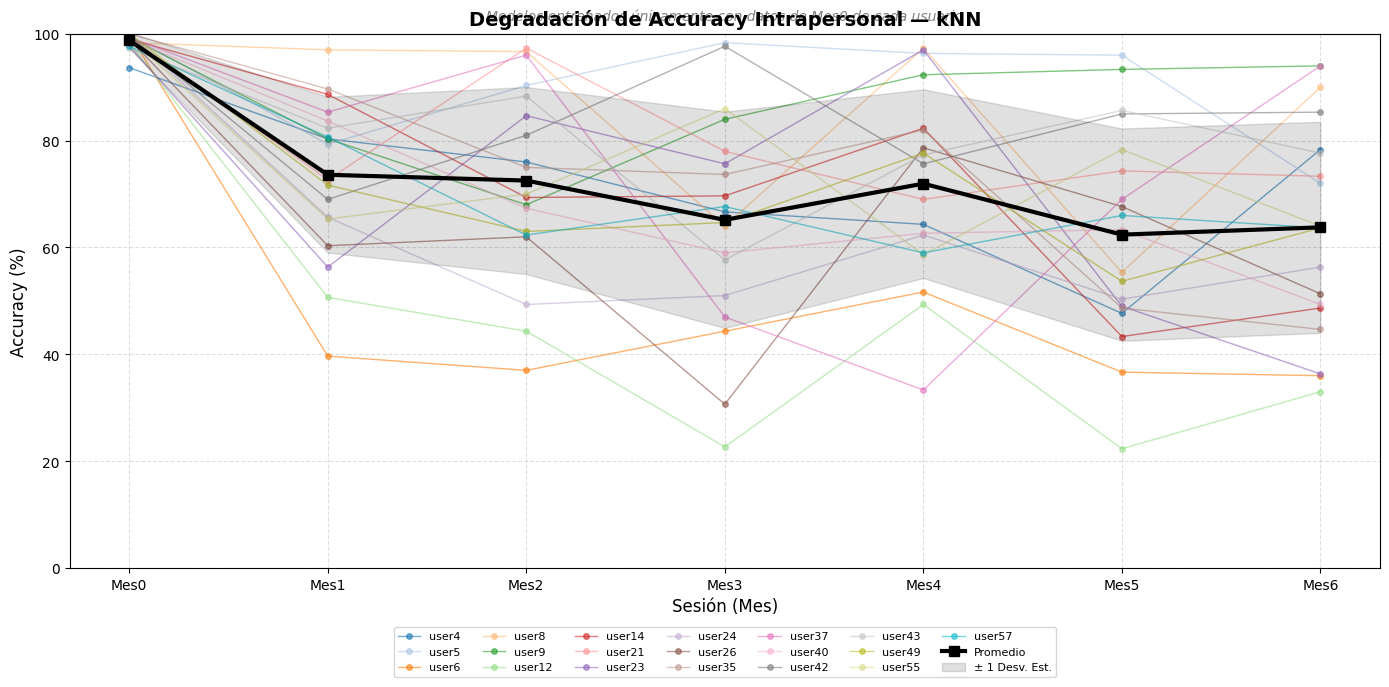


📈 Generando gráfica para SVM...
  📊 Figura guardada en: data/processed/results/figures/intrapersonal_accuracy_svm.png


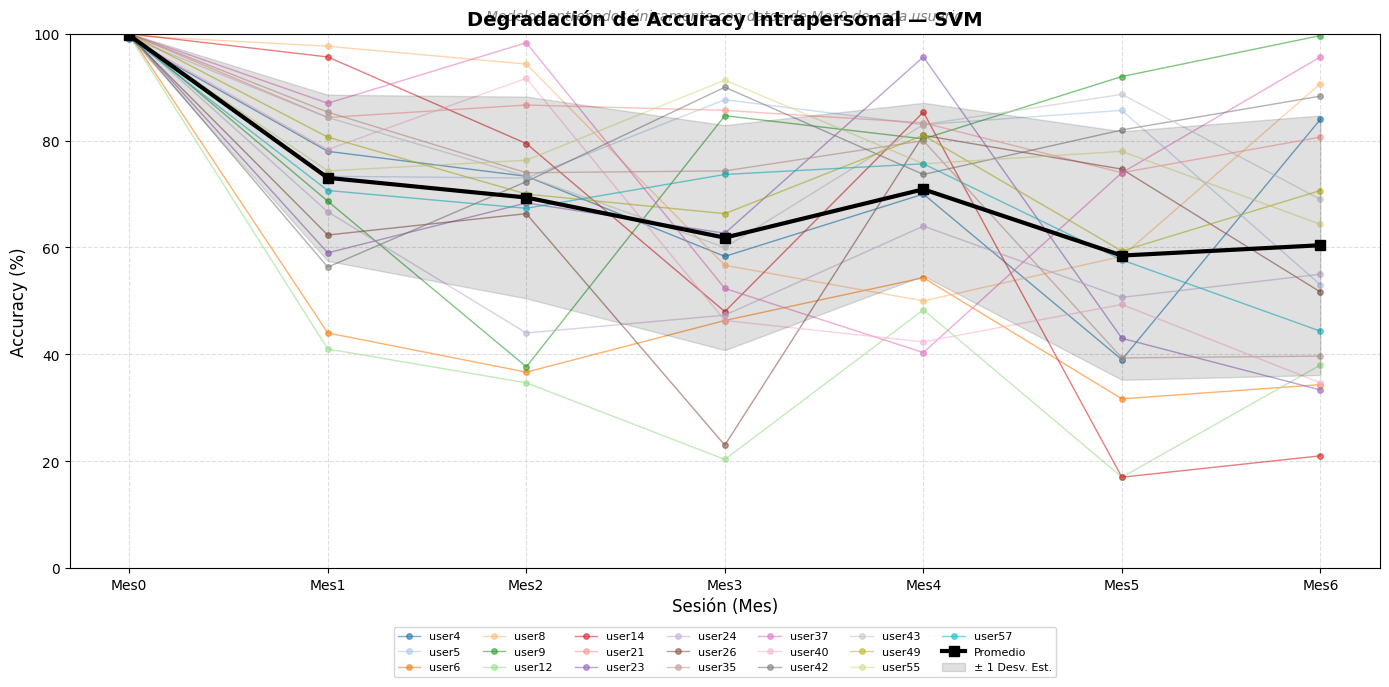


📈 Generando gráfica para ANN...
  📊 Figura guardada en: data/processed/results/figures/intrapersonal_accuracy_ann.png


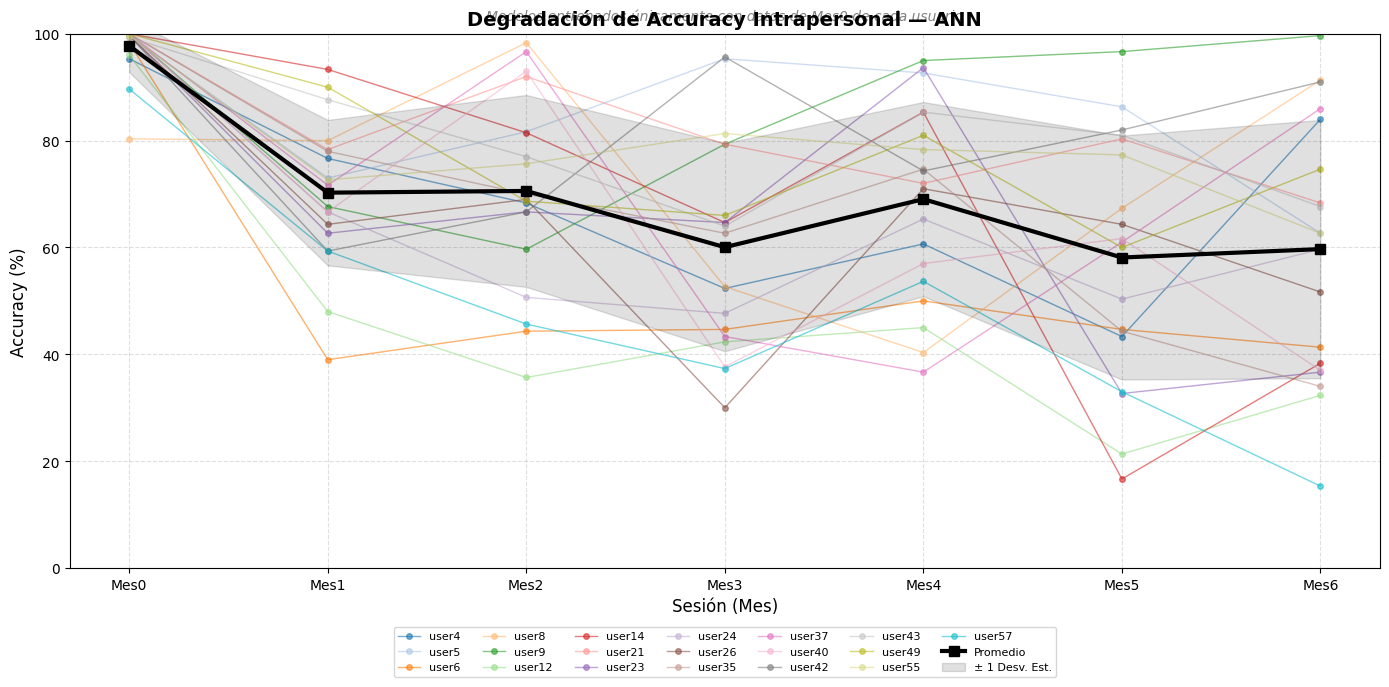


✅ Las 3 figuras han sido generadas y guardadas.


In [10]:
# Generar las 3 gráficas con colores consistentes
for model_name, file_suffix in [('kNN', 'knn'), ('SVM', 'svm'), ('ANN', 'ann')]:
    save_path = str(FIGURES_DIR / f'intrapersonal_accuracy_{file_suffix}.png')
    print(f'\n📈 Generando gráfica para {model_name}...')
    plot_intrapersonal_accuracy(
        results_df,
        model_name=model_name,
        user_colors=user_colors,
        save_path=save_path,
    )

print('\n✅ Las 3 figuras han sido generadas y guardadas.')

## 10. Resumen final

- **19 usuarios × 3 modelos = 57 modelos** entrenados con datos individuales de Mes0
- Evaluados contra **7 meses** (Mes0–Mes6) sin reentrenar
- Accuracy de Mes0 calculado mediante **validación cruzada estratificada** (5-fold)
- Resultados en formato largo (`intrapersonal_results_long.csv`) listos para Friedman/Wilcoxon
- 3 gráficas de degradación generadas en `data/processed/results/figures/`